# Теория ЛР 04: калибровка вероятностей и выбор правила решения

Этот ноутбук — теоретическая опора к практическим ноутбукам ЛР 04.
Здесь мы разбираем каждую идею простым языком, а затем подтверждаем ее формулами и небольшими примерами.


In [1]:
# Что делаем: Получаем прогнозы и рассчитываем метрики качества.
# Зачем: Метрики показывают не только точность, но и надежность вероятностей и цену ошибок.
# Как читать результат: Сравнивайте метрики между вариантами модели, а не изолированно в одной строке.
# Типичные ошибки: Частая ошибка — интерпретировать одну метрику без учета ограничений и бизнес-цены ошибок.

# Подключаем зависимости для этого шага.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss

# Строим визуализацию и проверяем интерпретируемость результата.
sns.set_theme(style='whitegrid')
np.random.seed(42)


## Раздел 1. Карта темы и связь с ЛР03/ЛР04

### Идея
В ЛР 03 мы выбрали модель, которая хорошо различает классы. В ЛР 04 мы отвечаем на другой вопрос: можно ли доверять вероятностям этой модели и какое правило решения дает наименьший практический риск.

### Формула
Формулы в этом разделе не нужны: здесь фиксируем логику маршрута.

### Мини-пример
Если модель говорит «вероятность 0.8», мы ожидаем, что примерно в 80% похожих случаев событие действительно произойдет.

### Как читать результат/график
Пока смотрим не на графики, а на последовательность шагов: качество вероятностей -> выбор порога -> итоговая проверка решения.

### Где это в практическом ноутбуке
- Ноутбук 1: проверяем калибровку вероятностей.
- Ноутбук 2: выбираем порог и итоговое правило решения.


## Раздел 2. Что такое вероятность модели и зачем нужна калибровка

### Идея
Вероятность модели — это не просто число, а обещание модели о частоте события. Калибровка проверяет, выполняется ли это обещание.

### Формула
Для группы объектов с прогнозом около $p$ доля положительного класса должна быть близка к $p$.

### Мини-пример
Если модель выдала 0.2 для 100 клиентов, то примерно 20 из них должны попасть в положительный класс.

### Как читать результат/график
Если фактическая доля сильно отличается от прогноза, вероятности плохо откалиброваны.

### Где это в практическом ноутбуке
Ноутбук 1, шаги с `uncalibrated`, `calibrated_sigmoid`, `calibrated_isotonic`.


In [2]:
# Что делаем: Выполняем очередной вычислительный блок текущего шага лабораторной работы.
# Зачем: Этот блок готовит промежуточный результат, который используется в следующей ячейке.
# Как читать результат: После выполнения проверьте вывод и убедитесь, что значения выглядят реалистично.
# Типичные ошибки: Частая ошибка — переходить дальше без проверки промежуточного результата.

# Мини-пример: проверяем «обещание вероятности» на игрушечных данных
predicted = np.array([0.2] * 10 + [0.8] * 10)
y_true = np.array([0,0,0,1,0,0,0,0,0,0, 1,1,1,1,0,1,1,1,0,1])

summary = pd.DataFrame({
    'group': ['p≈0.2', 'p≈0.8'],
    'predicted_probability': [predicted[:10].mean(), predicted[10:].mean()],
    'actual_rate': [y_true[:10].mean(), y_true[10:].mean()],
})
summary


,group,predicted_probability,actual_rate
0,p≈0.2,0.2,0.1
1,p≈0.8,0.8,0.8


## Раздел 3. Калибровка и ранжирование: в чем разница

### Идея
- Ранжирование (discrimination): модель правильно упорядочивает объекты по риску.
- Калибровка (calibration): численные вероятности соответствуют реальной частоте события.

### Формула
В этом разделе главное не формула, а различие целей: «кто выше риска» и «насколько велик риск в процентах».

### Мини-пример
Две модели могут иметь одинаковый ROC-AUC, но одна из них дает реалистичные вероятности, а другая — систематически завышенные.

### Как читать результат/график
Высокий ROC-AUC не гарантирует, что вероятности пригодны для выбора порога по стоимости ошибок.

### Где это в практическом ноутбуке
Ноутбук 1, сравнение метрик ранжирования (`roc_auc`, `pr_auc`) и метрик калибровки (`brier`, `log_loss`, `ece`).


In [3]:
# Что делаем: Выполняем очередной вычислительный блок текущего шага лабораторной работы.
# Зачем: Этот блок готовит промежуточный результат, который используется в следующей ячейке.
# Как читать результат: После выполнения проверьте вывод и убедитесь, что значения выглядят реалистично.
# Типичные ошибки: Частая ошибка — переходить дальше без проверки промежуточного результата.

# Игрушечный пример: одно и то же ранжирование, разная калибровка
score_rank = np.linspace(0.05, 0.95, 20)
model_a = score_rank
model_b = np.clip(score_rank * 1.35, 0, 1)  # искусственно завышаем уверенность

df_compare = pd.DataFrame({
    'rank_score': score_rank,
    'model_a_probability': model_a,
    'model_b_probability': model_b,
})
df_compare.head(10)


,rank_score,model_a_probability,model_b_probability
0,0.050000,0.050000,0.067500
1,0.097368,0.097368,0.131447
2,0.144737,0.144737,0.195395
3,0.192105,0.192105,0.259342
4,0.239474,0.239474,0.323289
5,0.286842,0.286842,0.387237
6,0.334211,0.334211,0.451184
7,0.381579,0.381579,0.515132
8,0.428947,0.428947,0.579079
9,0.476316,0.476316,0.643026


## Раздел 4. Метрики вероятностей: Brier, LogLoss, ECE

### Идея
Эти метрики отвечают на вопрос: «насколько хорошо модель оценивает вероятность события». Чем меньше значение, тем лучше.

### Формула
- $\text{Brier} = \frac{1}{N}\sum_{i=1}^{N}(p_i - y_i)^2$
- $\text{LogLoss} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log p_i + (1-y_i)\log(1-p_i)\right]$
- $\text{ECE} = \sum_{b=1}^{B}\frac{n_b}{N}|\text{conf}(b)-\text{acc}(b)|$

### Мини-пример
Если модель уверенно ошиблась (например, предсказала 0.99 для неверного класса), LogLoss резко увеличивается. Это и есть смысл фразы «штраф за уверенную ошибку».

### Как читать результат/график
- Brier: удобно сравнивать общее качество вероятностей.
- LogLoss: особенно чувствителен к рискованной уверенности.
- ECE: показывает разрыв между уверенностью и реальной частотой.

### Где это в практическом ноутбуке
Ноутбук 1, шаг расчета `calibration_audit`.


In [4]:
# Что делаем: Получаем прогнозы и рассчитываем метрики качества.
# Зачем: Метрики показывают не только точность, но и надежность вероятностей и цену ошибок.
# Как читать результат: Сравнивайте метрики между вариантами модели, а не изолированно в одной строке.
# Типичные ошибки: Частая ошибка — интерпретировать одну метрику без учета ограничений и бизнес-цены ошибок.

# Мини-расчет метрик на 8 наблюдениях
p = np.array([0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 0.99])
y = np.array([0, 0, 0, 1, 0, 1, 1, 0])

brier = brier_score_loss(y, p)
ll = log_loss(y, p, labels=[0, 1])

# Простая реализация ECE
bins = np.linspace(0.0, 1.0, 6)
ids = np.digitize(p, bins[1:-1], right=True)
ece = 0.0
# Итерируемся по объектам и последовательно накапливаем результаты.
for b in range(len(bins) - 1):
    mask = ids == b
    if mask.sum() == 0:
        continue
    conf = p[mask].mean()
    acc = y[mask].mean()
    ece += (mask.sum() / len(p)) * abs(conf - acc)

pd.DataFrame({'metric': ['Brier', 'LogLoss', 'ECE'], 'value': [brier, ll, ece]})


,metric,value
0,Brier,0.225325
1,LogLoss,0.893257
2,ECE,0.330000


## Раздел 5. Методы калибровки: Platt scaling и isotonic regression

### Идея
Калибровка перестраивает выходы модели так, чтобы вероятности лучше соответствовали фактам.

### Формула
- Platt scaling (`sigmoid`) использует логистическую функцию для коррекции вероятностей.
- Isotonic regression (`isotonic`) строит монотонную кусочно-линейную зависимость.

### Мини-пример
`sigmoid` обычно стабильнее на небольших данных, а `isotonic` может дать гибкую подстройку при достаточном объеме выборки.

### Как читать результат/график
Сравниваем до/после калибровки по Brier, LogLoss, ECE и по диаграмме надежности.

### Где это в практическом ноутбуке
Ноутбук 1, функции обучения вариантов `uncalibrated`, `calibrated_sigmoid`, `calibrated_isotonic`.


In [5]:
# Что делаем: Обучаем модель и, при необходимости, подбираем параметры.
# Зачем: На этом шаге формируется качество модели, которое дальше анализируется в метриках и графиках.
# Как читать результат: Смотрите на итоговые метрики и выбранные параметры: они должны соответствовать ожиданиям шага.
# Типичные ошибки: Частая ошибка — случайно обучить модель на неправильном split и получить смещенную оценку качества.

# Игрушечная демонстрация: сравнение до/после калибровки
x = np.linspace(-3, 3, 300)
true_prob = 1 / (1 + np.exp(-x))
y_sample = np.random.binomial(1, true_prob)

model_raw = np.clip(true_prob * 1.25, 0, 1)

# Platt-like коррекция на игрушечном примере
lr_cal = LogisticRegression(max_iter=200)
# Обучаем модель на подготовленных данных.
lr_cal.fit(model_raw.reshape(-1, 1), y_sample)
# Получаем вероятности классов для дальнейшего анализа.
model_sigmoid = lr_cal.predict_proba(model_raw.reshape(-1, 1))[:, 1]

# Isotonic коррекция
iso = IsotonicRegression(out_of_bounds='clip')
model_isotonic = iso.fit_transform(model_raw, y_sample)

compare = pd.DataFrame({
    'raw_brier': [brier_score_loss(y_sample, model_raw)],
    'sigmoid_brier': [brier_score_loss(y_sample, model_sigmoid)],
    'isotonic_brier': [brier_score_loss(y_sample, model_isotonic)],
})
compare


,raw_brier,sigmoid_brier,isotonic_brier
0,0.16925,0.156282,0.145287


## Раздел 6. Диаграмма надежности и разрыв калибровки

### Идея
Диаграмма надежности показывает, как средняя предсказанная вероятность соотносится с фактической частотой события.

### Формула
Идеальный случай: точки лежат на диагонали $y=x$.

### Мини-пример
Если точки выше диагонали, модель недооценивает вероятность; если ниже — переоценивает.

### Как читать результат/график
- Чем ближе к диагонали, тем лучше калибровка.
- Средний разрыв между кривой и диагональю можно использовать как простую визуальную меру ошибки.

### Где это в практическом ноутбуке
Ноутбук 1, шаг анализа надежности вероятностей.


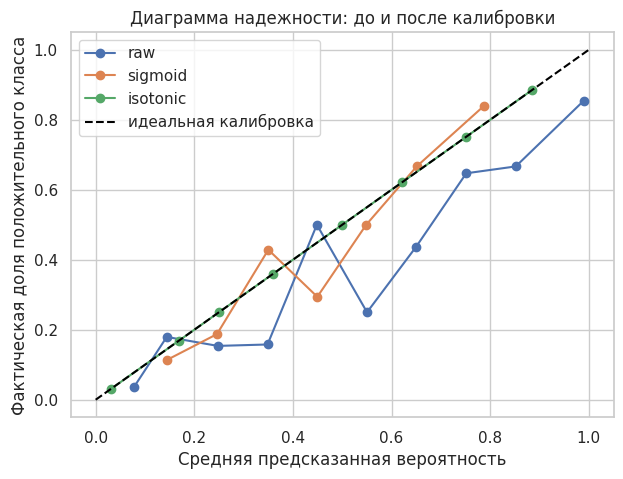

/tmp/ipykernel_980831/4289584637.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=scores_for_plot, x='variant', y='brier', palette='Blues_r')


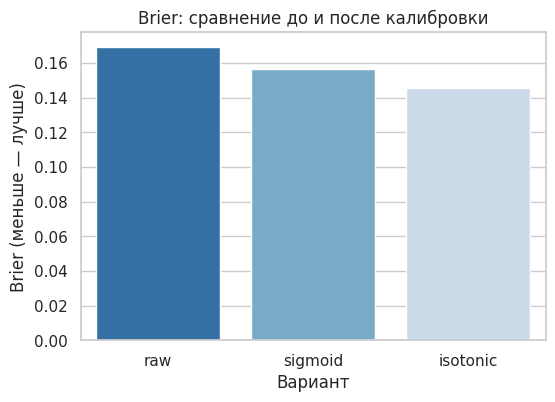

In [6]:
# Что делаем: Получаем прогнозы и рассчитываем метрики качества.
# Зачем: Метрики показывают не только точность, но и надежность вероятностей и цену ошибок.
# Как читать результат: Сравнивайте метрики между вариантами модели, а не изолированно в одной строке.
# Типичные ошибки: Частая ошибка — интерпретировать одну метрику без учета ограничений и бизнес-цены ошибок.

# Обязательный график 1: диаграмма надежности (идеальная диагональ + расхождение)
fig, ax = plt.subplots(figsize=(7, 5))

for name, prob in [
    ('raw', model_raw),
    ('sigmoid', model_sigmoid),
    ('isotonic', model_isotonic),
]:
    frac_pos, mean_pred = calibration_curve(y_sample, prob, n_bins=10, strategy='uniform')
    ax.plot(mean_pred, frac_pos, marker='o', label=name)

ax.plot([0, 1], [0, 1], '--', color='black', label='идеальная калибровка')
ax.set_title('Диаграмма надежности: до и после калибровки')
ax.set_xlabel('Средняя предсказанная вероятность')
ax.set_ylabel('Фактическая доля положительного класса')
ax.legend()
# Строим визуализацию и проверяем интерпретируемость результата.
plt.show()

# Обязательный график 2: сравнение до/после калибровки на игрушечных данных
scores_for_plot = pd.DataFrame({
    'variant': ['raw', 'sigmoid', 'isotonic'],
    'brier': [
        brier_score_loss(y_sample, model_raw),
        brier_score_loss(y_sample, model_sigmoid),
        brier_score_loss(y_sample, model_isotonic),
    ],
})

# Строим визуализацию и проверяем интерпретируемость результата.
plt.figure(figsize=(6, 4))
sns.barplot(data=scores_for_plot, x='variant', y='brier', palette='Blues_r')
plt.title('Brier: сравнение до и после калибровки')
plt.xlabel('Вариант')
plt.ylabel('Brier (меньше — лучше)')
plt.show()


## Раздел 7. Выбор порога как задача решения

### Идея
Порог переводит вероятность в действие. Поэтому мы выбираем порог не по привычке (`0.5`), а по цене ошибок и ограничениям риска.

### Формула
- решение: $\hat y = 1$, если $p\ge t$, иначе $0$;
- стоимость: $\text{ExpectedCost} = (FP\_cost\cdot FP + FN\_cost\cdot FN)/N$.

### Мини-пример
Если `FN` стоит в 5 раз дороже `FP`, часто выгодно снизить порог, чтобы уменьшить пропуски.

### Как читать результат/график
Смотрим одновременно `expected_cost`, `recall`, `f1`. Выбранный порог — это компромисс, а не «магическое число».

### Где это в практическом ноутбуке
Ноутбук 2, шаг `threshold_policy_grid` и выбор `selected_policies`.


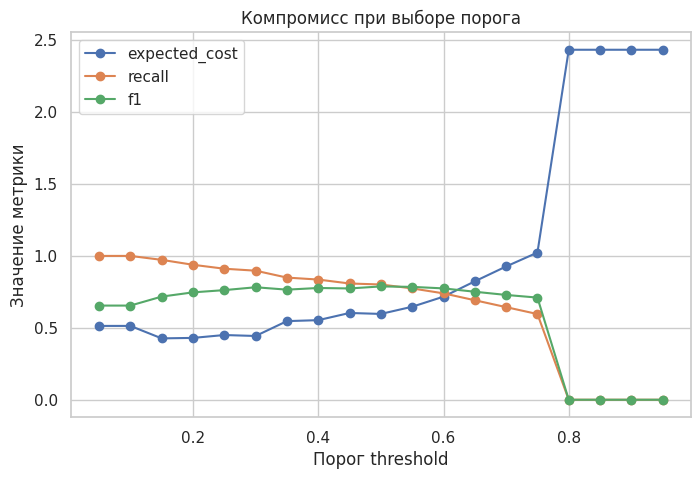

In [7]:
# Что делаем: Получаем прогнозы и рассчитываем метрики качества.
# Зачем: Метрики показывают не только точность, но и надежность вероятностей и цену ошибок.
# Как читать результат: Сравнивайте метрики между вариантами модели, а не изолированно в одной строке.
# Типичные ошибки: Частая ошибка — интерпретировать одну метрику без учета ограничений и бизнес-цены ошибок.

# Обязательный график 3: threshold -> expected_cost / recall / f1
thresholds = np.linspace(0.05, 0.95, 19)
rows = []

# Итерируемся по объектам и последовательно накапливаем результаты.
for t in thresholds:
    pred = (model_sigmoid >= t).astype(int)
    tp = ((pred == 1) & (y_sample == 1)).sum()
    fp = ((pred == 1) & (y_sample == 0)).sum()
    fn = ((pred == 0) & (y_sample == 1)).sum()

    precision = tp / max((tp + fp), 1)
    recall = tp / max((tp + fn), 1)
    f1 = 2 * precision * recall / max((precision + recall), 1e-12)
    expected_cost = (1 * fp + 5 * fn) / len(y_sample)

    rows.append({'threshold': t, 'expected_cost': expected_cost, 'recall': recall, 'f1': f1})

curve_df = pd.DataFrame(rows)

# Строим визуализацию и проверяем интерпретируемость результата.
plt.figure(figsize=(8, 5))
plt.plot(curve_df['threshold'], curve_df['expected_cost'], marker='o', label='expected_cost')
plt.plot(curve_df['threshold'], curve_df['recall'], marker='o', label='recall')
plt.plot(curve_df['threshold'], curve_df['f1'], marker='o', label='f1')
plt.title('Компромисс при выборе порога')
plt.xlabel('Порог threshold')
plt.ylabel('Значение метрики')
plt.legend()
plt.show()


## Раздел 8. Сегментный аудит правила решения

### Идея
Средняя метрика по всей выборке может скрывать проблемные группы. Сегментный аудит показывает, где цена ошибок особенно высока.

### Формула
Для каждого сегмента считаем отдельную стоимость ошибок и сравниваем между сегментами.

### Мини-пример
Даже при хорошей средней стоимости может оказаться, что у одного сегмента стоимость в 2-3 раза выше.

### Как читать результат/график
Ищем сегменты с максимальной стоимостью и анализируем, какая ошибка доминирует (`FP` или `FN`).

### Где это в практическом ноутбуке
Ноутбук 2, артефакт `segment_policy_audit.csv`.


/tmp/ipykernel_980831/532773746.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=seg_df, x='segment', y='expected_cost_per_100', palette='Oranges')


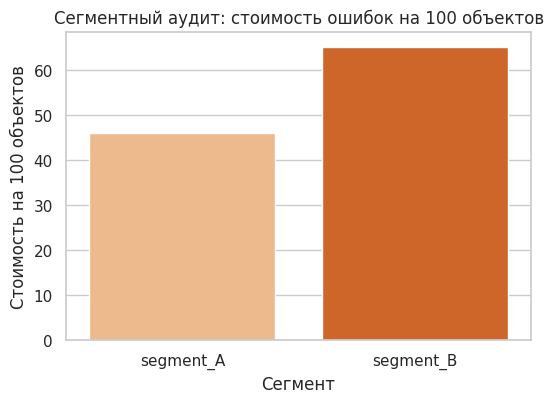

In [8]:
# Что делаем: Строим графики для визуальной проверки гипотез и выводов.
# Зачем: Графики помогают увидеть закономерности, которые неочевидны по одной таблице метрик.
# Как читать результат: Сопоставьте форму графика с числовыми метриками: они должны подтверждать друг друга.
# Типичные ошибки: Частая ошибка — делать вывод только по картинке без проверки числовых значений.

# Игрушечный сегментный аудит
segment = np.where(np.random.rand(len(y_sample)) > 0.5, 'segment_A', 'segment_B')
final_pred = (model_sigmoid >= 0.4).astype(int)

seg_rows = []
# Итерируемся по объектам и последовательно накапливаем результаты.
for seg in np.unique(segment):
    m = segment == seg
    y_seg = y_sample[m]
    p_seg = final_pred[m]

    fp = ((p_seg == 1) & (y_seg == 0)).sum()
    fn = ((p_seg == 0) & (y_seg == 1)).sum()
    cost_per_100 = 100 * (1 * fp + 5 * fn) / max(len(y_seg), 1)

    seg_rows.append({'segment': seg, 'expected_cost_per_100': cost_per_100})

seg_df = pd.DataFrame(seg_rows)
seg_df

# Строим визуализацию и проверяем интерпретируемость результата.
plt.figure(figsize=(6, 4))
sns.barplot(data=seg_df, x='segment', y='expected_cost_per_100', palette='Oranges')
plt.title('Сегментный аудит: стоимость ошибок на 100 объектов')
plt.xlabel('Сегмент')
plt.ylabel('Стоимость на 100 объектов')
plt.show()


## Раздел 9. Типичные ошибки и как их избежать

### Идея
Большинство ошибок в этой теме связаны не с кодом, а с логикой эксперимента.

### Формула
Формулы здесь не нужны; важны правила корректной постановки задачи.

### Мини-пример
- Ошибка 1: подбирать порог по `test`.
- Ошибка 2: задавать веса `FP/FN` «на глаз» без связи с предметной областью.
- Ошибка 3: смотреть только ROC-AUC и не проверять качество вероятностей.

### Как читать результат/график
Если итоговые цифры «слишком хорошие», сначала проверьте, не нарушен ли контракт по данным.

### Где это в практическом ноутбуке
- Ноутбук 1: запрещено использовать `test`.
- Ноутбук 2: финальная проверка на `test` делается один раз.


## Раздел 10. Проверь себя

1. Почему высокий ROC-AUC не гарантирует хорошую калибровку вероятностей?
2. Что означает фраза «LogLoss сильно наказывает уверенную ошибку»?
3. Почему порог нельзя подбирать на тестовой выборке?
4. Как изменение весов `FP/FN` влияет на выбор порога?
5. Зачем нужен сегментный аудит, если у нас уже есть средние метрики?

### Ожидаемая логика ответа
- Вы различаете ранжирование и калибровку.
- Вы объясняете смысл метрик простыми словами и связываете их с практическим риском.
- Вы соблюдаете контракт по данным: выбор на `validation`, `test` только для финальной оценки.
